# CMFV with a bit higher fidelity

## Setup

In [426]:
import numpy as np
import matplotlib.pyplot as plt
from typing import Callable
from dataclasses import dataclass

In [427]:
DEG_TO_RAD = np.pi/180
RAD_TO_DEG = 180/np.pi
M_TO_IN = 100 / 2.54
IN_TO_M = 2.54 / 100

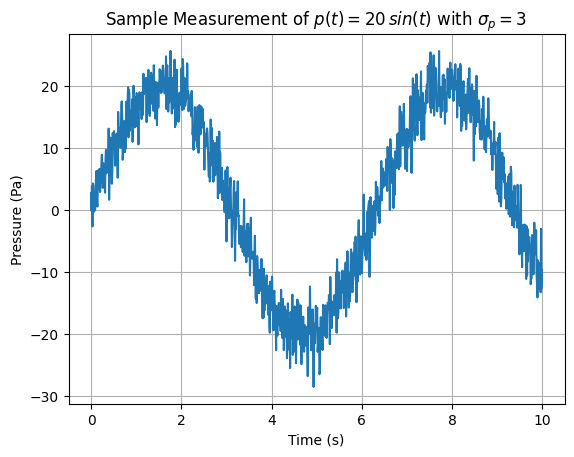

In [428]:
class PressureTransducer:
    def __init__(self, sigma_p: float, p0 = 0):
        self.sigma_p = sigma_p
        self.p_hat = p0

    def observe(self, p):
        """Adds noise to pressure and returns"""
        self.p_hat = np.random.normal(p, self.sigma_p)
        return self.p_hat
    
dt = 0.01
ts = np.arange(1000)*dt

sigma_p = 3 # Pa

ps = 20*np.sin(ts)
ducer = PressureTransducer(sigma_p, 0)
p_hat = [ducer.observe(p) for p in ps]

plt.title(rf"Sample Measurement of $p(t) = 20\,sin(t)$ with $\sigma_p = {sigma_p}$")
plt.xlabel("Time (s)")
plt.ylabel("Pressure (Pa)")
plt.plot(ts, p_hat )
plt.grid()
plt.show()

In [429]:
# Aside for figuring out the moment of inertia of this ball valve
R = 1 * IN_TO_M # in
rho = 9 # g/cm3??? No idea at all since that puts this 9000 kg/m^3
rho *= (100)**3 / 1000
V = 4/3 * np.pi * R**3
m_valve = rho*V
I_valve = m_valve * (R * np.pi/4)**2

print(f"Moment of inertia: {I_valve} kg*m2")

Moment of inertia: 0.0002458552374958548 kg*m2


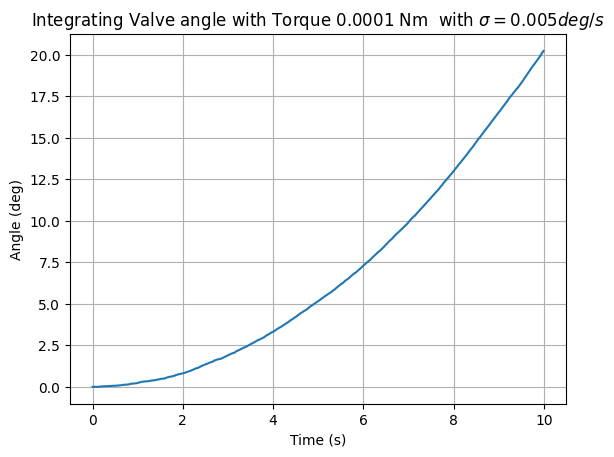

In [430]:
class ValveAngle:
    def __init__(self, dt: float, I_valve: float, theta0 = 0.0, sigma = 0, bounds = (0,90)):
        self.dt = dt
        self.I = I_valve

        # Basically the state
        self.theta = theta0
        self.omega = 0

        # Other info
        self.sigma = sigma
        self.bounds = bounds

    def step(self, Torque: float):
        """Integrates then adds noise"""
        alpha = Torque / self.I
        dt = self.dt

        self.omega += alpha * dt
        self.theta += self.omega * dt + 0.5*dt*dt*alpha

        self.theta += np.random.normal(0, self.sigma) # Maybe not add this?

        clipped_theta = np.clip(self.theta, *self.bounds)
        self.theta = clipped_theta

        if clipped_theta != self.theta:
            self.omega = 0


        return self.theta
        # return self.omega

    def reset(self):
        self.theta = 0
        self.omega = 0
    

dt = 0.01
ts = np.arange(1000)*dt # 10 seconds

Torque = 0.0001 # N/m
sigma_angle = 0.005 # deg/s

angle = ValveAngle(dt, I_valve, 0, sigma_angle)

# ducer = PressureTransducer(sigma_p, 0)
theta = [angle.step(Torque) for _ in ts]

title = rf"Integrating Valve angle with Torque {Torque} Nm  with $\sigma = {sigma_angle} deg/s$"
plt.title(title)
plt.xlabel("Time (s)")
plt.ylabel("Angle (deg)")
plt.plot(ts, theta)
plt.grid()
plt.show()

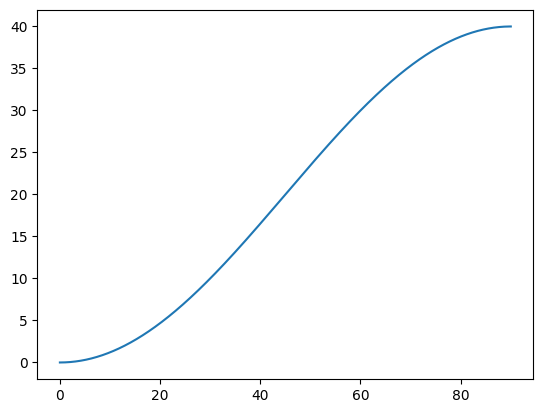

In [431]:
MAX_ANGLE_DEG = 90
angle_range = 90
E_eg = 40

t = np.linspace(0, angle_range, 100000)
y = -(np.cos((t/angle_range*np.pi)) - 1) / 2 * E_eg
plt.plot(t,y)
plt.show()

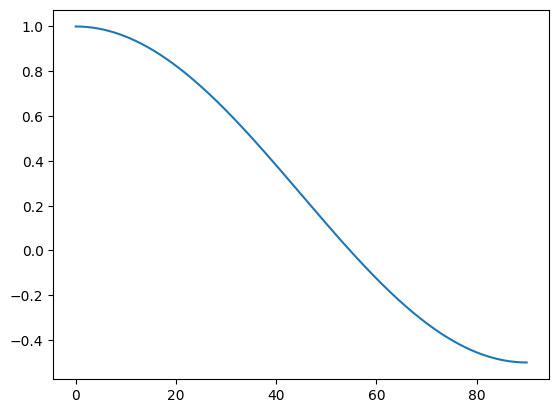

In [432]:
class Valve:
    # ASSUMPTION: incompressible / no density change
    # ASSUMPTION: no diameter change
    def __init__(self, rho = 1.0, A = 1.0):
        self.rho = rho
        self.A = A
        

    def across(self, p1: float, v1: float, theta_deg: float):
        """(p1, v1) --> p2 TODO: fix"""
        E1 = p1 + 0.5*self.rho*v1*v1
        
        # E_loss = (theta_deg/90)*E1 # Make this better but it's linear for now

        # Function I threw together from the last cell
        E_loss = -(np.cos((theta_deg/MAX_ANGLE_DEG*np.pi)) - 1) / 2 * E1 

        E2 = E1 - E_loss

        # Must be traveling at same speed since pipe is same A_cs
        v2 = v1
        p2 = E2 - 0.5*self.rho*v2*v2

        # p2 = p1 - (p1/90) * theta_deg

        return p2
    

p1 = 1
v1 = 1
angles = np.linspace(0, 90, 1000)
v = Valve()
ps = [v.across(p1, v1, angle) for angle in angles]
plt.plot(angles, ps)
plt.show()

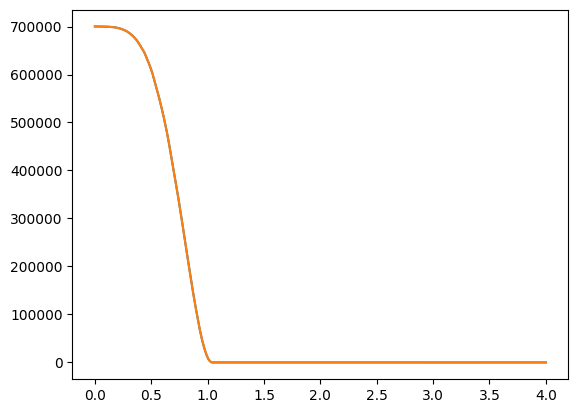

In [433]:
## Combined test

np.random.seed(173)

dt = 0.01
nsteps = 400

# ----- In order of blocks -----
sigma_angle = 0.05 # deg/s/s
valve_angle = ValveAngle(dt, I_valve, 0, sigma_angle)

valve = Valve()

sigma_p = 30 # Pa
ducer = PressureTransducer(sigma_p, 0)

# ----- ICs -----
theta_dot = .04 # deg/s/s
p_tank = 700_000 # Pa
v1 = 0.01 # m/s

# ----- Setup -----
angle = 0
ts = np.arange(nsteps+1)*dt

angles = np.zeros((nsteps+1))
ps = np.zeros((nsteps+1))
p_meas = np.zeros((nsteps+1))

angles[0] = angle
ps[0] = p_tank
p_meas[0] = ducer.observe(ps[0])

for i in range(nsteps):

    angle = valve_angle.step(theta_dot)
    
    # v = p_tank - p # idk causal?
    # v = np.sqrt(2*(p_tank - ps[i]))
    v = 0
    p = valve.across(p_tank, v, angle)

    angles[i+1] = angle
    ps[i+1] = p
    p_meas[i+1] = ducer.observe(p)
    


# plt.plot(ts, angles)
plt.plot(ts, p_meas)
plt.plot(ts, ps)
plt.show()

# ducer = PressureTransducer(sigma_p, 0)
# theta = [angle.step(theta_dot) for _ in ts]

### Controller part

In [434]:
MAX_TORQUE_NM = 10

class Controller:
    def __init__(self):
        pass

    def control(self):
        pass
        
# Kp has units of (deg/s)/Pa because of transfer function
class PDController(Controller):
    def __init__(self, Kp: float, Kd: float, dt: float):
        self.Kp = Kp
        self.Kd = Kd
        self.dt = dt
        self.err_prev = None
        

    def control(self, p_ref: float, p_meas: float):
        err = p_ref - p_meas

        if self.err_prev is None:
            self.err_prev = err
            de = 0
        else:
            de = (err - self.err_prev) / self.dt
            self.err_prev = err


        P_term = self.Kp * err
        D_term = self.Kd * de

        return -np.clip(P_term + D_term, -MAX_TORQUE_NM, MAX_TORQUE_NM) # deg /s/s
    
class PController(Controller):
    def __init__(self, Kp: float):
        self.Kp = Kp

    def control(self, p_ref: float, p_meas: float):
        command = self.Kp * (p_ref - p_meas)
        return -np.clip(command, -MAX_TORQUE_NM, MAX_TORQUE_NM) # deg /s/s
    
class PIController(Controller):
    def __init__(self, Kp: float, Ki: float, dt: float, windup_tolerance: float):
        self.Kp = Kp
        self.Ki = Ki
        self.dt = dt
        self.tol = windup_tolerance

        self.integraded_err = 0

    def control(self, p_ref: float, p_meas: float):
        err = p_ref - p_meas

        if abs(self.integraded_err) < self.tol:
            self.integraded_err += self.dt*err


        P_term = self.Kp * err
        I_term = self.Ki * self.integraded_err
        # print(de)
        # print(P_term)
        # print(D_term)
        return -np.clip(P_term + I_term, -MAX_TORQUE_NM, MAX_TORQUE_NM) # deg /s/s
    
class PIDController(Controller):
    def __init__(self, Kp: float, Ki: float, Kd: float, dt: float, windup_tolerance: float):
        self.Kp = Kp
        self.Ki = Ki
        self.Kd= Kd
        self.dt = dt

        self.integraded_err = 0
        self.tol = windup_tolerance

        self.err_prev = None


    def control(self, p_ref: float, p_meas: float):
        err = p_ref - p_meas


        # Integral
        if abs(self.integraded_err) < self.tol:
            self.integraded_err += self.dt*err

        # Derivative
        if self.err_prev is None:
            self.err_prev = err
            de = 0
        else:
            de = (err - self.err_prev) / self.dt
            self.err_prev = err


        P_term = self.Kp * err
        I_term = self.Ki * self.integraded_err
        D_term = self.Kd * de

        return -np.clip(P_term + I_term + D_term, -MAX_TORQUE_NM, MAX_TORQUE_NM) # deg /s/s

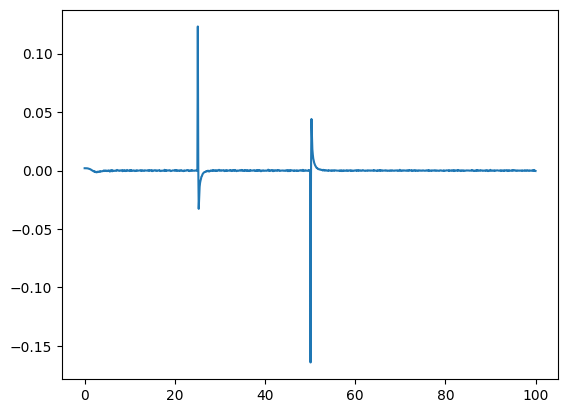

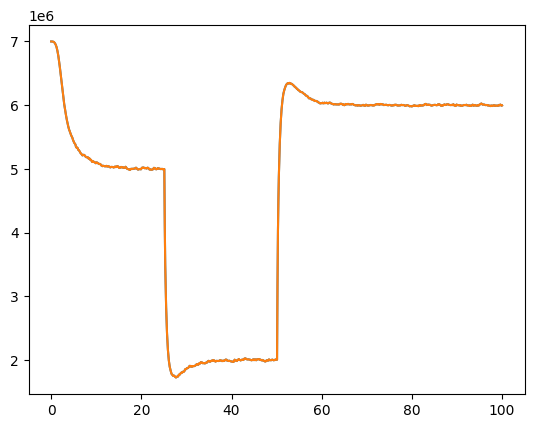

In [435]:
dt = 0.1
nsteps = 1000



p_tank = 7e6 # Pa
v1 = 0.01 # m/s

# ----- Setup -----

ts = np.arange(nsteps+1)*dt

angles = np.zeros((nsteps+1))
ps = np.zeros((nsteps+1))
p_meas = np.zeros((nsteps+1))
theta_dots = np.zeros((nsteps+1))

angle = 0
ps[0] = p_tank

# angle = 90
# ps[0] = 0

angles[0] = angle
p_meas[0] = ducer.observe(ps[0])


sigma_angle = 0.05 # deg/s/s
valve_angle = ValveAngle(dt, I_valve, 0, sigma_angle)


valve = Valve()

Kp = 1e-9
Kd = 4e-9
controller = PDController(Kp, Kd, dt)
p_setpoint = 5e6
theta_dots[0] = controller.control(p_setpoint, p_meas[0])


for i in range(nsteps):

    if ts[i] < 25:
        p_setpoint = 5e6
    elif ts[i] < 50:
        p_setpoint = 2e6
    elif ts[i] < 75:
        p_setpoint = 6e6

    angle = valve_angle.step(theta_dots[i])
    
    # v = p_tank - p # idk causal?
    # v = np.sqrt(2*(p_tank - ps[i]))
    v = v1
    p = valve.across(p_tank, v, angle)

    angles[i+1] = angle
    ps[i+1] = p
    p_meas[i+1] = ducer.observe(p)
    theta_dots[i+1] = controller.control(p_setpoint, p_meas[i])
    

a = 4.9
b = 6
plt.plot(ts, theta_dots)
# plt.xlim(a,b)
plt.show()

# plt.plot(ts, angles)
plt.plot(ts, p_meas)
plt.plot(ts, ps)
# plt.ylim(0,8e6)
# plt.plot(ts, ps)
# plt.xlim(a,b)
plt.show()



### Gettin that sim on

In [436]:
@dataclass
class CmfvSimOutputs:
    time: np.ndarray
    
    # Truth
    theta: np.ndarray
    p_truth: np.ndarray

    # Command
    theta_dot_cmd: np.ndarray
    p_setpoint: np.ndarray

    # Observation
    p_meas: np.ndarray

@dataclass 
class CmfvSimInputs:
    # Sim
    dt: float
    nsteps: int
    I_valve: int

    # 

    # Noise
    sigma_angle: float
    sigma_p: float



    seed: int | None = 273

@dataclass 
class CmfvSimInitialConditions:
    p_tank: float # Pa
    v: float # m/s
    theta: float

In [437]:
def run_sim(sim_in: CmfvSimInputs, ICs: CmfvSimInitialConditions, controller: Controller, p_r_func: Callable[[float], float]) -> CmfvSimOutputs:
    
    if sim_in.seed is not None:
        np.random.seed(sim_in.seed) 

    angle_integrator = ValveAngle(sim_in.dt, sim_in.I_valve, ICs.theta, sim_in.sigma_angle)
    valve = Valve(rho=1, A=1)
    
    p_out0 = valve.across(ICs.p_tank, ICs.v, ICs.theta) # Initial pressure on other side
    ducer = PressureTransducer(sim_in.sigma_p, p_out0)

    N = sim_in.nsteps
    dt = sim_in.dt

    ts = np.arange(N+1)*dt

    angles = np.zeros((N+1))
    p_truth = np.zeros((N+1))
    p_meas = np.zeros((N+1))
    p_setpoints = np.zeros((N+1))
    theta_dots = np.zeros((N+1))

    angles[0] = ICs.theta
    p_truth[0] = p_out0

    p_meas[0] = ducer.observe(p_truth[0])
    p_setpoints[0] = p_r_func(ts[0])
    theta_dots[0] = controller.control(p_setpoints[0], p_meas[0])

    for i in range(N):

        # Advance angle according to command
        angle = angle_integrator.step(theta_dots[i])
        
        # Just having velocity equal to starting one 
        v = ICs.v
        p_downstream = valve.across(ICs.p_tank, v, angle)

        angles[i+1] = angle
        p_truth[i+1] = p_downstream
        p_meas[i+1] = ducer.observe(p_downstream)

        # Get setpoint for the current step
        p_setpoints[i+1] = p_r_func(ts[i])
        theta_dots[i+1] = controller.control(p_setpoints[i+1], p_meas[i+1])

    return CmfvSimOutputs(
        time = ts,
        theta = angles,
        p_truth = p_truth,
        theta_dot_cmd = theta_dots,
        p_meas = p_meas,
        p_setpoint = p_setpoints
    )
    


In [438]:
def plot_sim(out: CmfvSimOutputs, start = 0, stop = -1, figsize = (12,8)):
    
    # Plot for pressure vs. setpoint
    plt.figure(figsize=figsize)
    # plt.
    # plt.subplot(3, 1, 1)
    plt.title("Pressure vs. Setpoint")
    plt.plot(out.time[start:stop], out.p_setpoint[start:stop], label="Setpoint", linestyle="-.", color="r")
    plt.plot(out.time[start:stop], out.p_meas[start:stop], label="Measured pressure", color="tab:orange")
    plt.plot(out.time[start:stop], out.p_truth[start:stop], label="Pressure", color="tab:blue")
    plt.legend()
    plt.xlabel("Time [s]")
    plt.ylabel("Pressure [Pa]")
    plt.show()

    # Plot for angle vs. time
    plt.figure(figsize=figsize)
    plt.title("Valve angle")
    plt.plot(out.time[start:stop], out.theta[start:stop], label="Valve Angle")
    plt.xlabel("Time [s]")
    plt.ylabel("Angle [deg]")
    plt.show()

    # Plot for angle_dot vs. time
    plt.figure(figsize=figsize)
    plt.title("Valve angle command")
    plt.plot(out.time[start:stop], out.theta_dot_cmd[start:stop], label="Angle command")
    plt.xlabel("Time [s]")
    plt.ylabel("Command [deg/s]")
    plt.show()


## Preliminary Runs

In [445]:
sim_in = CmfvSimInputs(
    dt = 0.01,
    nsteps = 4000,
    I_valve=I_valve,
    sigma_angle = 0.01, # deg/s
    sigma_p = 30, # Pa
    # seed = 173
)

sim_ICs = CmfvSimInitialConditions(
    p_tank = 7e6, # Pa
    v = .01, # m/s
    theta = 90
)

def setpoint(t):
    return 5e6
    return np.floor(t/4) * 1e6 + 1e6

# Kp = 0.000005
# controller = PController(Kp)

Kp = 1e-8
Kd = 4e-8
controller = PDController(Kp, Kd, dt)

sim_out = run_sim(sim_in, sim_ICs, controller, setpoint)

start = 0
stop = -1

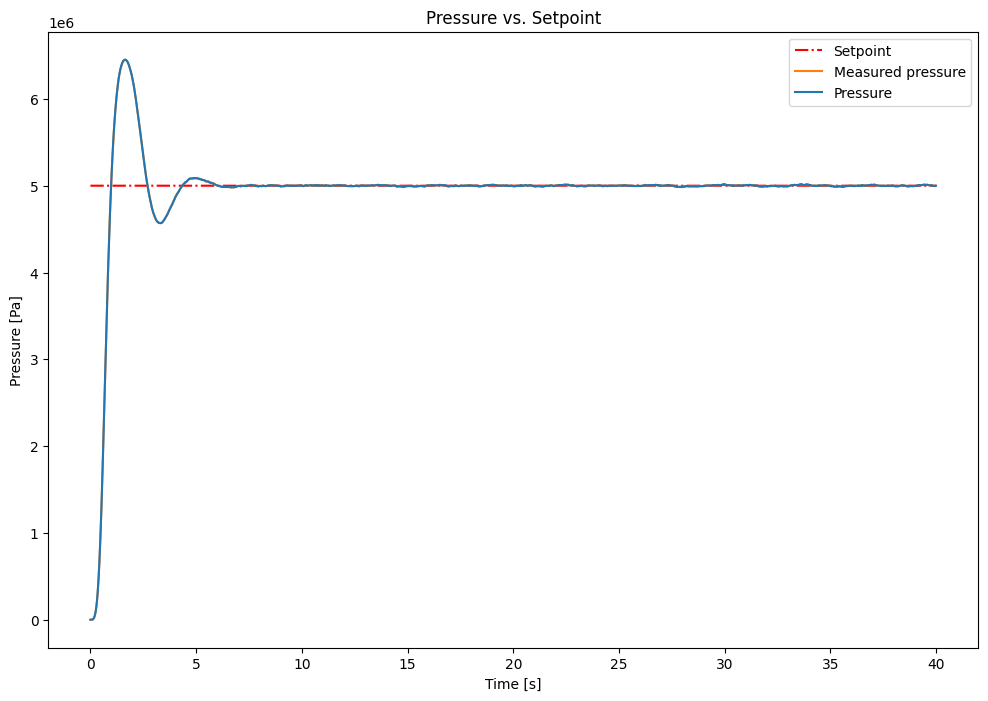

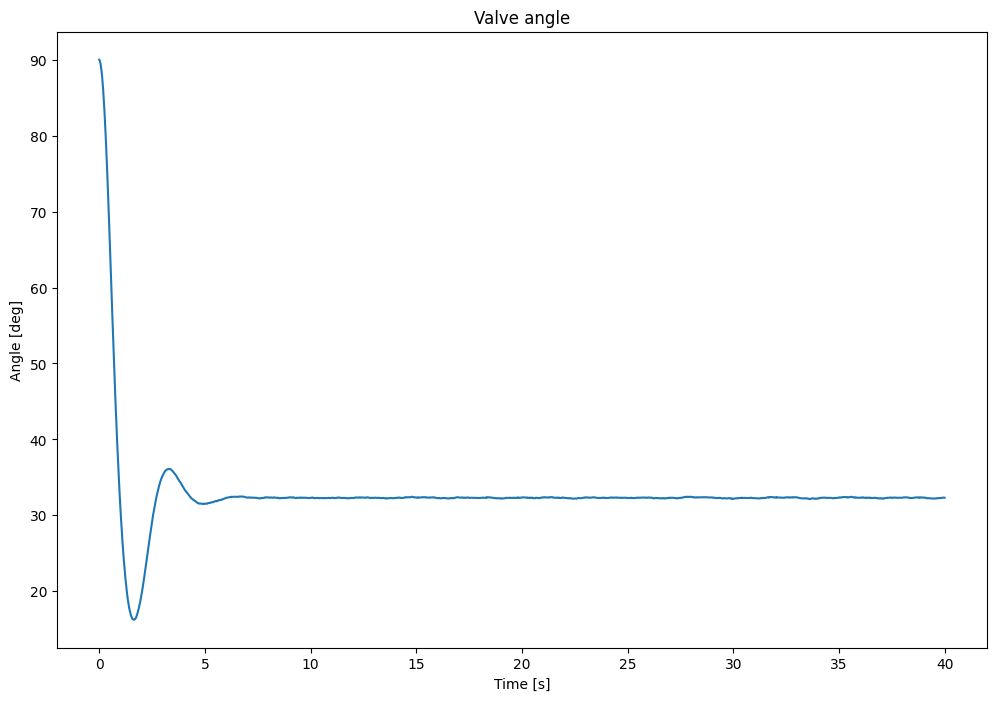

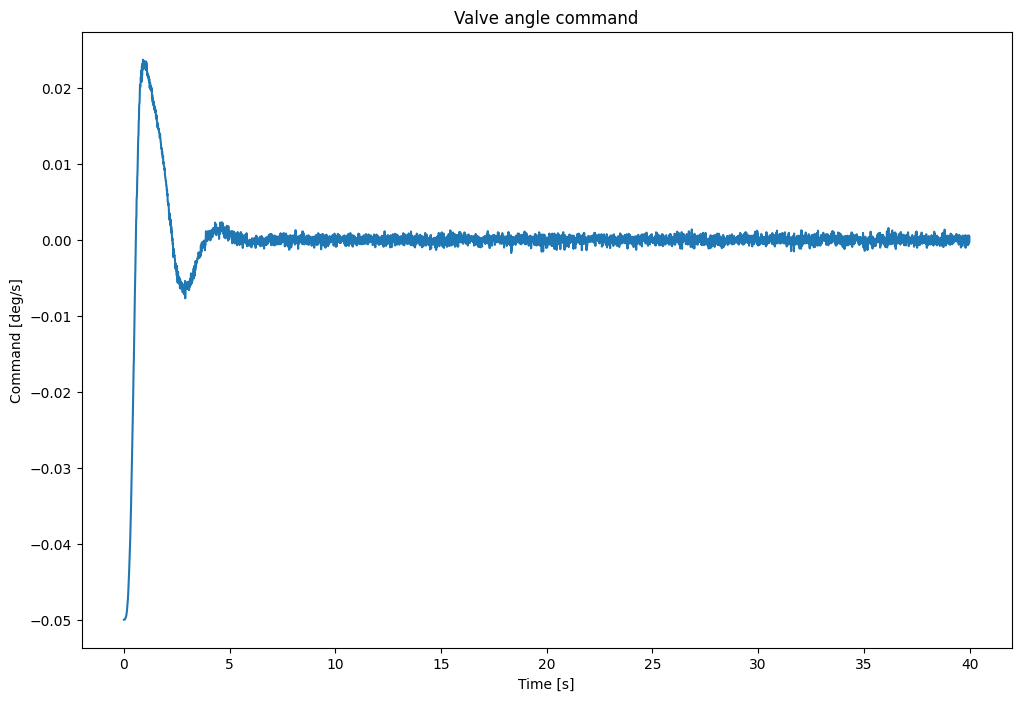

In [449]:
plot_sim(sim_out, start=start, stop=stop)


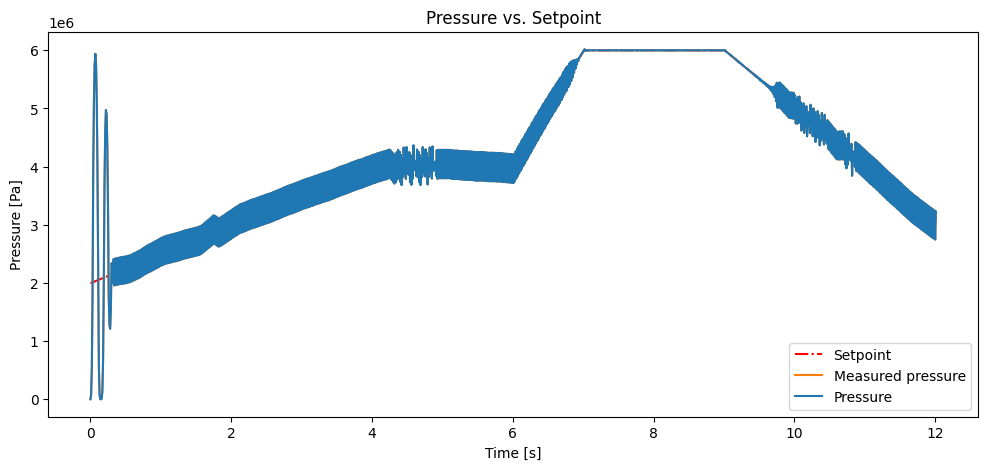

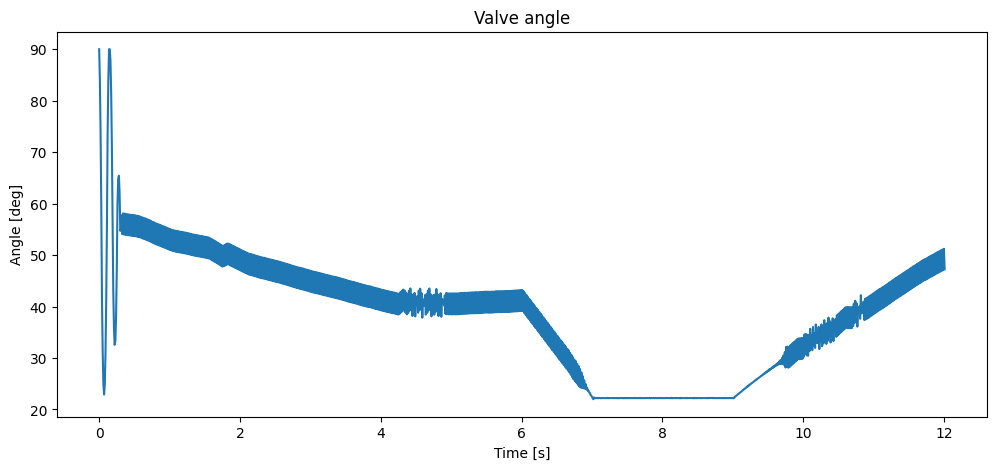

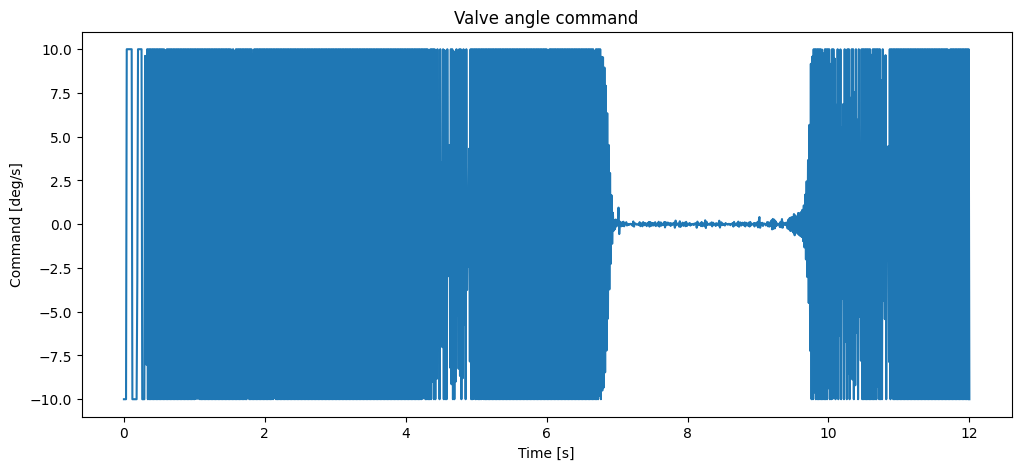

In [441]:
# This is where we need to turn to different types of controllers
def rampish(t):
    """(0, 3e6)--> (4, 4e6) then (6, 4e6)--> (7, 6e6) then (9, 6e6)--> (12, 3e6) then 3e6"""
    if t < 4:
        return 2e6*t/4 + 2e6
    elif t < 6:
        return 4e6
    elif t < 7:
        return 2e6*(t-6) + 4e6
    elif t < 9:
        return 6e6
    elif t < 12:
        return -1e6*(t-9) + 6e6

Kp = 0.00005
controller = PController(Kp)

sim_out = run_sim(sim_in, sim_ICs, controller, rampish)

start = 0
stop = -1

plot_sim(sim_out, start=start, stop=stop, figsize=(12,5))

In [442]:
sim_in = CmfvSimInputs(
    dt = 0.01,
    nsteps = 4000,
    sigma_angle = 0.01, # deg/s
    sigma_p = 1000, # Pa
    # seed = 173
)

sim_ICs = CmfvSimInitialConditions(
    p_tank = 7e6, # Pa
    v = 1, # m/s
    theta = 90
)

def setpoint(t):
    return np.floor(t/4) * 1e6 + 1e6


# Iterating on these for it to work with the ramp
Kp = 0.0007
# Kp = 0
Kd = .000003
# Kd = 0
controller = PDController(Kp, Kd, sim_in.dt)
# controller = PController(Kp)

sim_out = run_sim(sim_in, sim_ICs, controller, setpoint)

start = 0
stop = -1

plot_sim(sim_out, start=start, stop=stop, figsize=(12,5))

TypeError: CmfvSimInputs.__init__() missing 1 required positional argument: 'I_valve'